#### Binary File Handling

In [3]:
# Problems with working in text mode
'''
- can't work with binary files like images
- not good for other data types like int/float/list/tuples
'''

# opening binary file in text mode
try:
    with open('screenshot1.png', 'r') as f:
        f.read() # Throws an error
except Exception as e:
    print(e)

'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte


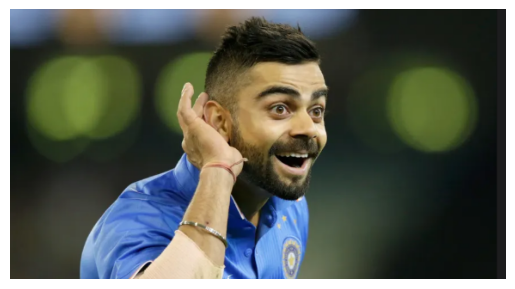

In [4]:
# working with binary file
with open('screenshot1.png','rb') as f:
    with open('screenshot_copy.png','wb') as wf: # This file will create is not already present in current directory
        wf.write(f.read()) # reading one file and writing onto another

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('screenshot_copy.png')
plt.imshow(img)
plt.axis('off')
plt.show()

In [5]:
# working with other data types
with open('sample.txt','w') as f:
    f.write(5) # Throws an error - you can only write string in the files not any other datatypes

TypeError: write() argument must be str, not int

In [6]:
with open('sample.txt','w') as f:
    f.write('5')

with open('sample.txt','r') as f:
    print(int(f.read()) + 5)
    
# nither you write nor read the data type other than string

10


In [7]:
# Handling dictonaries
d = {
    'name':'nitish',
    'age':33,
    'gender':'male'
}

with open('sample.txt','w') as f:
    f.write(str(d))

with open('sample.txt','r') as f:
    print(dict(f.read())) # Throws an error - string cannot able to convert into dictonary

ValueError: dictionary update sequence element #0 has length 1; 2 is required

#### Serialization and Deserialization
- Serialization - process of converting python data types to JSON format
- Deserialization - process of converting JSON to python data types

In [ ]:
import json

# List
L = [1, 2, 3, 4]

with open('demo.json', 'w') as f:
    json.dump(obj=L, fp=f)

In [9]:
# Dict
d = {
    'name':'nitish',
    'age':33,
    'gender':'male'
}

with open('demo.json','w') as f:
    json.dump(d, f, indent=4)

In [10]:
with open('demo.json', 'r') as f:
    j = json.load(f)
    print(j['name'])

nitish


In [11]:
with open('demo.json', 'r') as f:
    d = json.load(f) # d is an object by which you can access all the keys
    print(d)
    print(type(d))

{'name': 'nitish', 'age': 33, 'gender': 'male'}
<class 'dict'>


In [15]:
# bytes are not serializable
try:
    with open(file="Screenshot2.png", mode='rb') as img:
        with open(file="virat.json", mode='w') as jsn:
            json.dump(obj=img.read(), fp=jsn)
except TypeError as e:
    print(e)

Object of type bytes is not JSON serializable


In [ ]:
# Tuple
t = (1,2,3,4,5)

with open('demo.json', 'w') as f:
    json.dump(t, f) # When you store tuple in the json file then, it will get stored in the form of list and not in the tuple.

    # When you deserialize it the result is also in the from of list only

In [17]:
# Serializing and Deserializing custom objects
class Person:
    def __init__(self,fname,lname,age,gender):
        self.fname = fname
        self.lname = lname
        self.age = age
        self.gender = gender

person = Person('Nitish', 'Singh', 33, 'male')

In [18]:
# Note - You have to searilize an object in different way else error - Object of type Person is not JSON serializable

def show_object(person):
    if isinstance(person,Person):
        return {'name':person.fname + ' ' + person.lname,'age':person.age,'gender':person.gender}

with open('demo.json','w') as f:
    json.dump(person, f, default=show_object, indent=4)

In [19]:
with open('demo.json','r') as f:
    d = json.load(f)
    print(d)
    print(type(d)) # The type is what you stored during writing into the file

{'name': 'Nitish Singh', 'age': 33, 'gender': 'male'}
<class 'dict'>


`Pickling` is the process whereby a Python object hierarchy is converted into a byte stream, and `unpickling` is the inverse operation, whereby a byte stream (from a binary file or bytes-like object) is converted back into an object hierarchy.

In [20]:
class Person:
    def __init__(self,name,age):
        self.name = name
        self.age = age

    def display_info(self):
        print('Hi my name is',self.name,'and I am ',self.age,'years old')

p = Person('nitish', 33)

In [21]:
# pickle dump
import pickle
with open('person.pkl','wb') as f:
    pickle.dump(p,f)

In [22]:
# pickle load
import pickle
with open('person.pkl','rb') as f:
    p = pickle.load(f)

In [23]:
p.display_info()

Hi my name is nitish and I am  33 years old


In [ ]:
# Pickle Vs Json
'''
- Pickle lets the user to store data in binary format. JSON lets the user store data in a human-readable text format.
'''

Error - When you run a pickle file on your devide which is made onto another device you will get an error - Cant get attribut 'class_name' on module __main__ - This is because The error you're encountering is likely due to the fact that the class definition of the object being unpickled is not available in the current namespace. When you pickle an object, the pickle module stores the module and class names, but not the actual class definition. When you unpickle the object, Python needs to be able to find the class definition in the same module and with the same name.